In [1]:
!pip install statsmodels

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [3]:
# LOAD DATA
df = pd.read_csv("../data/processed/matches_with_features.csv")
df.head()

,date,home_team,away_team,home_goals,away_goals,tournament,city,country,neutral,elo_home,elo_away,elo_diff
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,1500.000000,1500.000000,0.000000
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,1500.000000,1500.000000,0.000000
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,1490.000000,1510.000000,-20.000000
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,1499.424989,1500.575011,-1.150023
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,1500.541911,1499.458089,1.083822


#### GOAL

To model the Number of Goals Scored(count data). Hence I used a Poisson regression & not a linear regression since Goals are integers (0,1,2…) where low values dominate
& matches Poisson assumptions based on exploratory analysis.

#### 1. Build Home Goals Model


In [4]:
# Evaluate Elo difference between home & away teams
df['elo_diff'] = df['elo_home'] - df['elo_away'] 

# TRAIN POISSON MODEL
X_home = sm.add_constant(df['elo_diff'])  # Add Intercept
y_home = df['home_goals']

poisson_home = sm.GLM(y_home, X_home, family=sm.families.Poisson()).fit()

print(f"Poisson Home Goals Model Summary: {poisson_home.summary()}")

Poisson Home Goals Model Summary:                  Generalized Linear Model Regression Results                  
Dep. Variable:             home_goals   No. Observations:                49257
Model:                            GLM   Df Residuals:                    49255
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -83668.
Date:                Wed, 27 May 2026   Deviance:                       70849.
Time:                        11:22:03   Pearson chi2:                 7.24e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2323
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4

#### 2. Away Goals Model

In [5]:
X_away = sm.add_constant(-df["elo_diff"])   # Why -ve elo? If home is stronger → away is weaker hence flip perspective.
y_away = df["away_goals"]

poisson_away = sm.GLM(y_away, X_away, family=sm.families.Poisson()).fit()

print(f"Poisson Away Goals Model Summary: {poisson_away.summary()}")


Poisson Away Goals Model Summary:                  Generalized Linear Model Regression Results                  
Dep. Variable:             away_goals   No. Observations:                49257
Model:                            GLM   Df Residuals:                    49255
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -70657.
Date:                Wed, 27 May 2026   Deviance:                       66606.
Time:                        11:22:03   Pearson chi2:                 6.91e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1816
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1

## 📊 Poisson Regression Model (Goals Prediction)

We model the number of goals scored using a **Poisson regression**.

---

### 🧠 Model Formulation

The model learns:

$ \log(\lambda_{home}) = \beta_0 + \beta_1 \cdot \text{elo\_diff} $

---

### 🔍 What each term means

- $ \lambda_{home} $ → Expected number of goals scored by the home team  
- $ \beta_0 $ → Intercept (baseline scoring level)  
- $ \beta_1 $ → Effect of Elo difference  
- $ \text{elo\_diff} $ → Strength difference between teams  

---

### 🔄 Why use log?

We model the **log of expected goals** instead of goals directly because:

- Poisson requires: $ \lambda > 0 $
- Linear models can produce negative values ❌

Using log ensures:

$ \lambda_{home} = \exp(\beta_0 + \beta_1 \cdot \text{elo\_diff}) $

---

### 🎯 Key Idea

> We first compute a linear combination, then transform it using the exponential function.

---

### ⚙️ Step-by-step

1. Compute linear score:

$ z = \beta_0 + \beta_1 \cdot \text{elo\_diff} $

2. Convert to expected goals:

$ \lambda = \exp(z) $

---

### 🧠 Intuition

- If $ \text{elo\_diff} $ increases → stronger home team  
- Then $ z $ increases  
- Then $ \lambda $ increases  

👉 Stronger teams are expected to score more goals

---

### 🔥 Why this works

This is called a **log-link function**, and it is standard in Poisson regression.

It ensures:
- Predictions are always positive ✔  
- Relationship remains interpretable ✔  

---

### 🚀 Connection to Your Project

You are modeling:

$ \text{Team Strength (Elo)} \rightarrow \text{Expected Goals} $

This is the core bridge between:
- rating systems  
- probabilistic match prediction  

#### 3. Predict Expected Goals

In [6]:
# PREDICT EXPECTED GOALS
df['lambda_home'] = poisson_home.predict(X_home)
df['lambda_away'] = poisson_away.predict(X_away)

df[["lambda_home", "lambda_away"]].describe()

,lambda_home,lambda_away
count,49257.000000,49257.000000
mean,1.757050,1.182735
std,0.725653,0.525277
min,0.200924,0.140065
25%,1.293345,0.850466
50%,1.631995,1.089786
75%,2.066860,1.391104
max,11.523793,9.821635


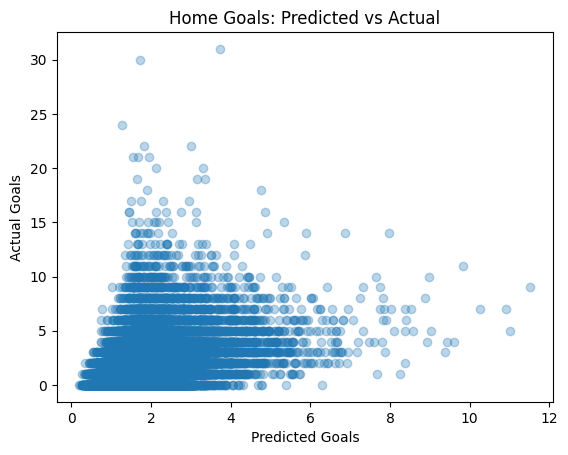

In [7]:
# Comparing Predictions vs Reality
plt.scatter(df["lambda_home"], df["home_goals"], alpha=0.3)
plt.xlabel("Predicted Goals")
plt.ylabel("Actual Goals")
plt.title("Home Goals: Predicted vs Actual")
plt.show()

In [8]:
# Global variables (will store trained parameters)
beta_home = None
beta_away = None


def train_poisson_model(data_path):
    """
    Train Poisson models and store coefficients globally.
    """

    global beta_home, beta_away

    df = pd.read_csv(data_path)

    # Feature engineering
    df['elo_diff'] = df['elo_home'] - df['elo_away']

    # --- HOME MODEL ---
    X_home = sm.add_constant(df['elo_diff'])
    y_home = df['home_goals']

    poisson_home = sm.GLM(y_home, X_home, family=sm.families.Poisson()).fit()

    # --- AWAY MODEL ---
    X_away = sm.add_constant(-df['elo_diff'])
    y_away = df['away_goals']

    poisson_away = sm.GLM(y_away, X_away, family=sm.families.Poisson()).fit()

    # Store learned parameters
    beta_home = poisson_home.params.values
    beta_away = poisson_away.params.values

    print("✅ Poisson model trained")


def get_lambda(team_a, team_b, elo_dict):
    """
    Compute expected goals for both teams using trained model.
    """

    if beta_home is None or beta_away is None:
        raise ValueError("Model not trained. Call train_poisson_model() first.")

    elo_a = elo_dict.get(team_a, 1700)
    elo_b = elo_dict.get(team_b, 1700)

    elo_diff = elo_a - elo_b

    # Home perspective
    X_home = np.array([1, elo_diff])
    lambda_home = np.exp(np.dot(beta_home, X_home))

    # Away perspective
    X_away = np.array([1, -elo_diff])
    lambda_away = np.exp(np.dot(beta_away, X_away))

    return lambda_home, lambda_away

### XGBoost Model

In [9]:
# Relevant Imports
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [10]:
print(df.columns)

Index(['date', 'home_team', 'away_team', 'home_goals', 'away_goals',
       'tournament', 'city', 'country', 'neutral', 'elo_home', 'elo_away',
       'elo_diff', 'lambda_home', 'lambda_away'],
      dtype='object')


In [11]:
df.sample(5)

,date,home_team,away_team,home_goals,away_goals,tournament,city,country,neutral,elo_home,elo_away,elo_diff,lambda_home,lambda_away
22468,1997-11-19,Senegal,Mali,1,2,Friendly,Dakar,Senegal,False,1496.790768,1463.970775,32.819994,1.729150,1.025607
24096,2000-01-26,Guatemala,Panama,1,1,Friendly,Guatemala City,Guatemala,False,1508.785316,1467.351502,41.433814,1.765349,1.003544
37713,2014-05-25,Republic of Ireland,Turkey,1,2,Friendly,Dublin,Republic of Ireland,False,1684.709220,1690.877604,-6.168384,1.574366,1.131696
31235,2007-09-08,Nigeria,Lesotho,2,0,African Cup of Nations qualification,Warri,Nigeria,False,1707.947332,1327.073138,380.874195,3.994000,0.425950
4395,1957-01-28,Jamaica,Trinidad and Tobago,2,1,Friendly,Kingston,Jamaica,False,1471.296830,1544.130368,-72.833538,1.341120,1.339135


In [12]:
# Create Target Variable(Predicted Variable) (Goals)
def encode_result(row):
    if row["home_goals"] > row["away_goals"]:
        return 2 # home win
    elif row["home_goals"] < row["away_goals"]:
        return 1 # away win
    else:
        return 0 # draw
    
df['result'] = df.apply(encode_result, axis=1)

In [13]:
features = [
    "elo_home",
    "elo_away",
    "elo_diff",
    "lambda_home",
    "lambda_away"
]

In [14]:
# TRAIN/TEST SPLIT
X = df[features]
y = df["result"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train XGBoost Model
xgb_model = XGBClassifier(
    objective="multi:softprob",  # gives probabilities (IMPORTANT)
    num_class=3,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train)

xgb_model.save_model("xgb_model.json")

# EVALUATE MODEL PERFORMANCE
y_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.570239545269996


In [15]:
from sklearn.metrics import log_loss, brier_score_loss
import numpy as np

# Probabilities
y_proba_xgb = xgb_model.predict_proba(X_test)

# Log Loss
xgb_logloss = log_loss(y_test, y_proba_xgb)

# Brier Score (multiclass version)
xgb_brier = np.mean(np.sum((y_proba_xgb - np.eye(3)[y_test])**2, axis=1))

print("XGB Log Loss:", xgb_logloss)
print("XGB Brier Score:", xgb_brier)

XGB Log Loss: 0.9263667506082528
XGB Brier Score: 0.5468943568166377


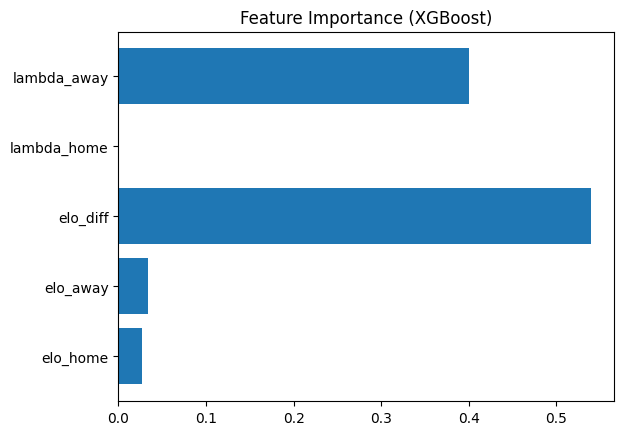

In [16]:
# EVALUATE FEATURE PERFORMANCE
importances = xgb_model.feature_importances_

plt.barh(features, importances)
plt.title("Feature Importance (XGBoost)")
plt.show()

In [17]:
from sklearn.calibration import CalibratedClassifierCV

# Calibrating XGBoost
xgb_calibrated = CalibratedClassifierCV(
    xgb_model,
    method='isotonic',  # or 'sigmoid'
    cv=3
)

xgb_calibrated.fit(X_train, y_train)

,estimator,"XGBClassifier..._class=3, ...)"
,method,'isotonic'
,cv,3
,n_jobs,None
,ensemble,'auto'
,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None


In [18]:
# Evaluate XGBoost Again.
xgb_probs_cal = xgb_calibrated.predict_proba(X_test)

from sklearn.metrics import log_loss

log_loss_cal = log_loss(y_test, xgb_probs_cal)

brier_cal = np.mean(
    np.sum((xgb_probs_cal - np.eye(3)[y_test])**2, axis=1)
)

print("Calibrated Log Loss:", log_loss_cal)
print("Calibrated Brier:", brier_cal)

Calibrated Log Loss: 0.9267175907609145
Calibrated Brier: 0.5470636561209524


In [19]:
# MATCH PREDICTION FUNCTION
def predict_match_xgb(team1, team2, elo_dict, model):
    # Get elo scores
    elo_home = elo_dict.get(team1, 1500)
    elo_away = elo_dict.get(team2, 1500)

    # Use poisson model to get lamda values
    lam_home, lam_away = get_lambda(
        team1, team2,
        elo_dict,
        beta_home,
        beta_away
    )

    data = pd.DataFrame([{
        "elo_home": elo_home,
        "elo_away": elo_away,
        "elo_diff": elo_home - elo_away,
        "lambda_home": lam_home,
        "lambda_away": lam_away
    }])

    probs = model.predict_proba(data)[0]

    return probs  # [away, draw, home]



In [20]:
def simulate_match_xgb(team1, team2, elo_dict, model):

    probs = predict_match_xgb(team1, team2, elo_dict, model)

    outcome = np.random.choice(
        ["away", "draw", "home"],
        p=probs
    )

    if outcome == "home":
        return team1
    elif outcome == "away":
        return team2
    else:
        return np.random.choice([team1, team2])

### Training Hybrid Model

In [24]:
import pandas as pd
import numpy as np
import sys, os
from sklearn.model_selection import train_test_split
sys.path.append(os.path.abspath(".."))
from src.models.hybrid import HybridWorldCupModel
import json

In [25]:
# Load data
df = pd.read_csv("../data/processed/matches_with_features.csv")
elo_df = pd.read_csv("../data/processed/final_elo.csv")

# adjust column names if needed
elo_dict = dict(zip(elo_df.iloc[:, 0], elo_df.iloc[:, 1]))

print(list(elo_dict.items())[:10])

[('Scotland', 1687.3624537040316), ('England', 1892.582129098532), ('Wales', 1684.7676522402085), ('Northern Ireland', 1567.9519199266515), ('United States', 1770.951242272253), ('Uruguay', 1817.2450735423083), ('Austria', 1771.0417702760358), ('Hungary', 1702.2716173527422), ('Argentina', 1985.2581690488155), ('Belgium', 1833.8543712375351)]


In [29]:
# Training Hybrid Model
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# Initialize Hybrid Model
model = HybridWorldCupModel()

# Train Hybrid Model
model.fit(
    train_df=train_df,
    elo_dict=elo_dict,
    test_df=test_df
)

# Evaluate Model
model.evaluate(test_df)

# Save Model
model.save("../models/hybrid.pkl")

📊 TEST LOG LOSS: 0.9117689321206854
📊 TEST ACC: 0.5795777507105156
✅ Model trained

📊 FINAL EVALUATION
Log Loss: 0.9117689321206854
Accuracy: 0.5795777507105156
Brier: 0.5379347765575244
